In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.21.0


In [5]:
import sys

print(sys.executable)

C:\Users\User\anaconda3\envs\pneumonia_ai\python.exe


In [6]:
import matplotlib
print(matplotlib.__version__)

3.11.0


In [7]:
TRAIN_PATH = "combined_dataset/train"
VALID_PATH = "combined_dataset/valid"
TEST_PATH  = "combined_dataset/test"

print(TRAIN_PATH)
print(VALID_PATH)
print(TEST_PATH)

combined_dataset/train
combined_dataset/valid
combined_dataset/test


In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [9]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=10,

    width_shift_range=0.10,

    height_shift_range=0.10,

    zoom_range=0.15,

    shear_range=0.10,

    brightness_range=[0.9, 1.1],

    horizontal_flip=False,

    fill_mode="nearest"
)

valid_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [10]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

validation_generator = valid_test_datagen.flow_from_directory(
    VALID_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = valid_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 5630 images belonging to 3 classes.
Found 1916 images belonging to 3 classes.
Found 902 images belonging to 3 classes.


In [11]:
print("\nTrain Images :", train_generator.samples)
print("Validation Images :", validation_generator.samples)
print("Test Images :", test_generator.samples)

print("\nClass Mapping")
print(train_generator.class_indices)


Train Images : 5630
Validation Images : 1916
Test Images : 902

Class Mapping
{'Normal': 0, 'Pneumonia': 1, 'Tuberculosis': 2}


In [12]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = train_generator.classes

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(weights))

print("\nClass Weights")
print(class_weights)


Class Weights
{0: np.float64(1.2586630896490052), 1: np.float64(0.6312366857270995), 2: np.float64(1.6094911377930246)}


In [10]:
%pip install h5py

Note: you may need to restart the kernel to use updated packages.


In [13]:
# ==========================================================
# Build EfficientNetV2B0 Model
# ==========================================================

base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze the backbone
base_model.trainable = False

# Classification Head
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dropout(0.4)(x)

x = Dense(256, activation="relu")(x)

x = BatchNormalization()(x)

x = Dropout(0.3)(x)

outputs = Dense(3, activation="softmax")(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

print("Model created successfully!")

Model created successfully!


In [14]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               0 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_project_conv (Conv2D) │ (None, 112, 112, 16)      │           4,608 │ stem_activation[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_project_bn            │ (None, 112, 112, 16)      │              64 │ block1a_project_conv[0][0] │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_project_activation    │ (None, 112, 112, 16)      │               0 │ block1a_project_bn[0][0]   │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_expand_conv (Conv2D)  │ (None, 56, 56, 64)        │           9,216 │ block1a_project_activatio… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_expand_bn             │ (None, 56, 56, 64)        │             256 │ block2a_expand_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_expand_activation     │ (None, 56, 56, 64)        │               0 │ block2a_expand_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_project_conv (Conv2D) │ (None, 56, 56, 32)        │           2,048 │ block2a_expand_activation… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_project_bn            │ (None, 56, 56, 32)        │             128 │ block2a_project_conv[0][0] │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2b_expand_conv (Conv2D)  │ (None, 56, 56, 128)       │          36,86

 Total params: 6,254,163 (23.86 MB)

 Trainable params: 331,779 (1.27 MB)

 Non-trainable params: 5,922,384 (22.59 MB)

In [13]:
import h5py
print(h5py.__version__)

3.12.1


In [14]:
import sys
print(sys.executable)

C:\Users\User\anaconda3\envs\pneumonia_ai\python.exe


In [15]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [16]:
import h5py
print(h5py.__version__)

3.12.1


In [12]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [13]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_efficientnet.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [14]:
print("train_generator" in globals())
print("validation_generator" in globals())
print("model" in globals())
print("class_weights" in globals())

True
True
True
True


In [15]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7478 - loss: 0.6400
Epoch 1: val_loss improved from None to 0.34240, saving model to best_efficientnet.keras

Epoch 1: finished saving model to best_efficientnet.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 291s 1s/step - accuracy: 0.7478 - loss: 0.6400 - val_accuracy: 0.9040 - val_loss: 0.3424 - learning_rate: 1.0000e-04
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8528 - loss: 0.3700
Epoch 2: val_loss improved from 0.34240 to 0.25321, saving model to best_efficientnet.keras

Epoch 2: finished saving model to best_efficientnet.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - accuracy: 0.8528 - loss: 0.3700 - val_accuracy: 0.9045 - val_loss: 0.2532 - learning_rate: 1.0000e-04
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8787 - loss: 0.3124
Epoch 3: val_loss improved from 0.25321 to 0.19316, saving model to best_efficientnet.keras

Epoch 3: finished saving model to best_efficientnet.keras
176

In [17]:
from tensorflow.keras.models import load_model

model = load_model("best_efficientnet.keras")

In [18]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_acc)

29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 420ms/step - accuracy: 0.9424 - loss: 0.1386
Test Loss : 0.13863348960876465
Test Accuracy : 0.9423503279685974


In [19]:
y_pred = model.predict(test_generator)

29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 429ms/step


In [20]:
import numpy as np
from sklearn.metrics import classification_report

# True labels
y_true = test_generator.classes

# Predicted labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Class names
class_names = list(test_generator.class_indices.keys())

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

      Normal       0.85      0.96      0.90       241
   Pneumonia       0.98      0.91      0.95       411
Tuberculosis       0.98      0.98      0.98       250

    accuracy                           0.94       902
   macro avg       0.94      0.95      0.94       902
weighted avg       0.95      0.94      0.94       902



In [22]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


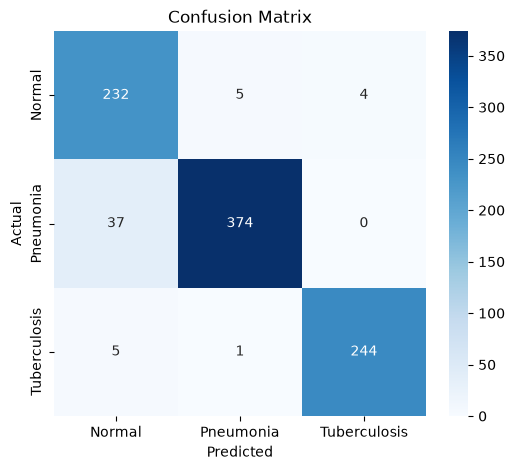

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

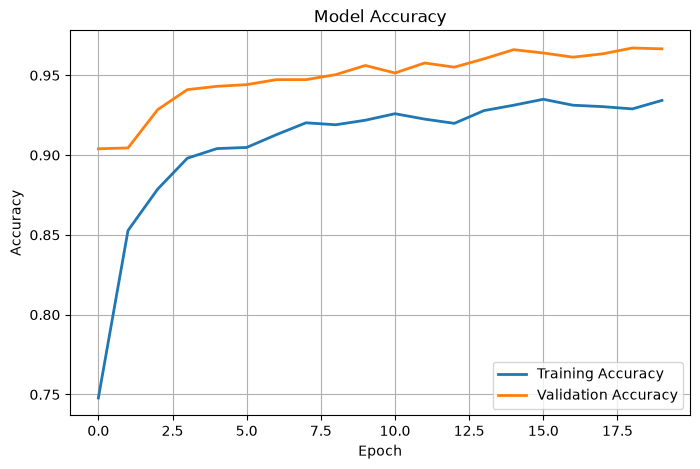

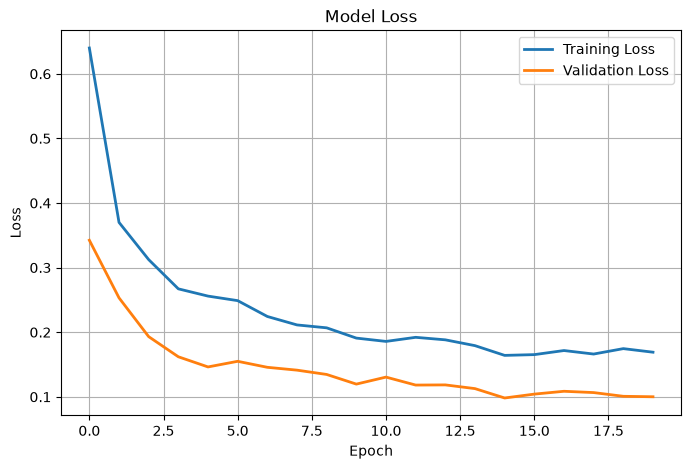

In [24]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("accuracy_plot.png", dpi=300)
plt.show()


# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("loss_plot.png", dpi=300)
plt.show()

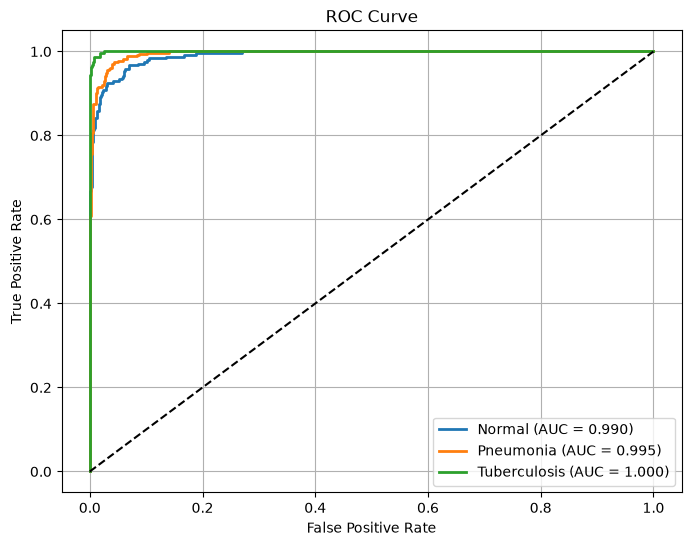

In [25]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# True labels
y_true = test_generator.classes

# Convert into binary
y_true_bin = label_binarize(y_true, classes=[0,1,2])

# Predicted probabilities
y_score = y_pred

class_names = ["Normal","Pneumonia","Tuberculosis"]

plt.figure(figsize=(8,6))

for i in range(3):

    fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_score[:,i])

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.grid(True)

plt.savefig("roc_curve.png",dpi=300)

plt.show()

In [26]:
model.save("Final_EfficientNet_Pneumonia_TB.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [27]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
)

print(report)

with open("classification_report.txt","w") as f:
    f.write(report)

print("Classification Report Saved!")

              precision    recall  f1-score   support

      Normal       0.85      0.96      0.90       241
   Pneumonia       0.98      0.91      0.95       411
Tuberculosis       0.98      0.98      0.98       250

    accuracy                           0.94       902
   macro avg       0.94      0.95      0.94       902
weighted avg       0.95      0.94      0.94       902

Classification Report Saved!


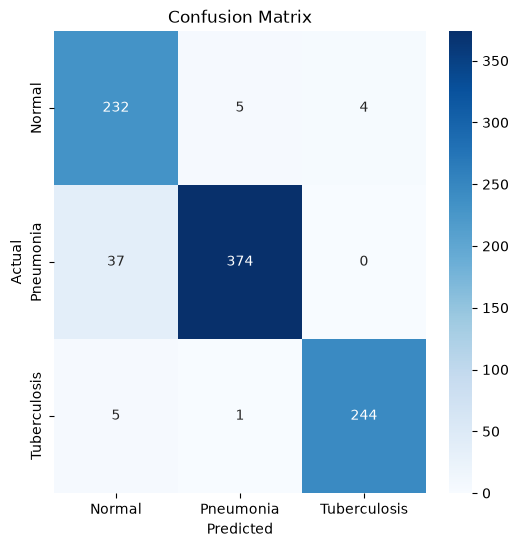

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true,y_pred_classes)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png",dpi=300)

plt.show()

In [29]:
import pickle

with open("training_history.pkl","wb") as f:
    pickle.dump(history.history,f)

print("Training History Saved!")

Training History Saved!


In [ ]:
%pip install grad-cam opencv-python matplotlib pillow

     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
     -- ------------------------------------- 0.5/7.8 MB 2.8 MB/s eta 0:00:03
     ------ --------------------------------- 1.3/7.8 MB 2.8 MB/s eta 0:00:03
     ------------- -------------------------- 2.6/7.8 MB 3.7 MB/s eta 0:00:02
     ------------------ --------------------- 3.7/7.8 MB 4.1 MB/s eta 0:00:01
     -------------------------- ------------- 5.2/7.8 MB 4.6 MB/s eta 0:00:01
     --------------------------------- ------ 6.6/7.8 MB 5.0 MB/s eta 0:00:01
     ---------------------------------------- 7.8/7.8 MB 5.1 MB/s  0:00:01
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproj

In [14]:
for layer in model.layers:
    print(layer.name)

input_layer
rescaling
normalization
stem_conv
stem_bn
stem_activation
block1a_project_conv
block1a_project_bn
block1a_project_activation
block2a_expand_conv
block2a_expand_bn
block2a_expand_activation
block2a_project_conv
block2a_project_bn
block2b_expand_conv
block2b_expand_bn
block2b_expand_activation
block2b_project_conv
block2b_project_bn
block2b_drop
block2b_add
block3a_expand_conv
block3a_expand_bn
block3a_expand_activation
block3a_project_conv
block3a_project_bn
block3b_expand_conv
block3b_expand_bn
block3b_expand_activation
block3b_project_conv
block3b_project_bn
block3b_drop
block3b_add
block4a_expand_conv
block4a_expand_bn
block4a_expand_activation
block4a_dwconv2
block4a_bn
block4a_activation
block4a_se_squeeze
block4a_se_reshape
block4a_se_reduce
block4a_se_expand
block4a_se_excite
block4a_project_conv
block4a_project_bn
block4b_expand_conv
block4b_expand_bn
block4b_expand_activation
block4b_dwconv2
block4b_bn
block4b_activation
block4b_se_squeeze
block4b_se_reshape
block4b

In [3]:
import tensorflow as tf

model = tf.keras.models.load_model("Final_EfficientNet_Pneumonia_TB.keras")

In [5]:
for layer in model.layers:
    print(layer.name)

input_layer
rescaling
normalization
stem_conv
stem_bn
stem_activation
block1a_project_conv
block1a_project_bn
block1a_project_activation
block2a_expand_conv
block2a_expand_bn
block2a_expand_activation
block2a_project_conv
block2a_project_bn
block2b_expand_conv
block2b_expand_bn
block2b_expand_activation
block2b_project_conv
block2b_project_bn
block2b_drop
block2b_add
block3a_expand_conv
block3a_expand_bn
block3a_expand_activation
block3a_project_conv
block3a_project_bn
block3b_expand_conv
block3b_expand_bn
block3b_expand_activation
block3b_project_conv
block3b_project_bn
block3b_drop
block3b_add
block4a_expand_conv
block4a_expand_bn
block4a_expand_activation
block4a_dwconv2
block4a_bn
block4a_activation
block4a_se_squeeze
block4a_se_reshape
block4a_se_reduce
block4a_se_expand
block4a_se_excite
block4a_project_conv
block4a_project_bn
block4b_expand_conv
block4b_expand_bn
block4b_expand_activation
block4b_dwconv2
block4b_bn
block4b_activation
block4b_se_squeeze
block4b_se_reshape
block4b

In [10]:
import os

os.chdir(r"C:\Users\User\Desktop\Pneumonia & TB Detection\Chest_Xray_AI")

print(os.getcwd())

C:\Users\User\Desktop\Pneumonia & TB Detection\Chest_Xray_AI


In [3]:
import os

print(os.path.exists("app.py"))

True


In [3]:
import os

print(os.listdir("utils"))

['.ipynb_checkpoints', 'ai_report.py', 'constants.py', 'grandcam.py', 'pdf_generator.py', 'predictor.py', 'preprocess.py', 'severity.py', '__init__.py', '__pycache__']


In [4]:
import os

print(os.listdir("utils"))

['.ipynb_checkpoints', 'ai_report.py', 'constants.py', 'gradcam.py', 'pdf_generator.py', 'predictor.py', 'preprocess.py', 'severity.py', '__init__.py', '__pycache__']


In [2]:
!pip install ollama

  Using cached ollama-0.6.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.1 MB 699.0 kB/s eta 0:00:03
   ---------- ----------------------------- 0.5/2.1 MB 699.0 kB/s eta 0:00:03
   --------------- ------------------------ 0.8/2.1 MB 745.8 kB

In [3]:
import ollama

print("Ollama installed successfully!")

Ollama installed successfully!


In [9]:
import sys
print(sys.executable)

C:\Users\User\anaconda3\envs\pneumonia_ai\python.exe


In [6]:
!pip --version

pip 26.1.2 from C:\Users\User\anaconda3\envs\pneumonia_ai\Lib\site-packages\pip (python 3.11)



In [ ]:
import os

os.chdir(r"C:\Users\User\Desktop\Pneumonia & TB Detection\Chest_Xray_AI")

print(os.getcwd())
!streamlit run app.py

C:\Users\User\Desktop\Pneumonia & TB Detection\Chest_Xray_AI


In [18]:
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               0 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_project_conv (Conv2D) │ (None, 112, 112, 16)      │           4,608 │ stem_activation[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_project_bn            │ (None, 112, 112, 16)      │              64 │ block1a_project_conv[0][0] │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_project_activation    │ (None, 112, 112, 16)      │               0 │ block1a_project_bn[0][0]   │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_expand_conv (Conv2D)  │ (None, 56, 56, 64)        │           9,216 │ block1a_project_activatio… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_expand_bn             │ (None, 56, 56, 64)        │             256 │ block2a_expand_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_expand_activation     │ (None, 56, 56, 64)        │               0 │ block2a_expand_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_project_conv (Conv2D) │ (None, 56, 56, 32)        │           2,048 │ block2a_expand_activation… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_project_bn            │ (None, 56, 56, 32)        │             128 │ block2a_project_conv[0][0] │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2b_expand_conv (Conv2D)  │ (None, 56, 56, 128)       │          36,86

 Total params: 6,254,163 (23.86 MB)

 Trainable params: 331,779 (1.27 MB)

 Non-trainable params: 5,922,384 (22.59 MB)

None
